<a href="https://colab.research.google.com/github/K-Tanaka8/rossmann-sales-forecasting-lightgbm/blob/main/rossmann_sales_forecasting_lightgbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [837]:

'''
#  Rossmann_Sales_Forecasting_LightGBM_Model
このノートブックは、Google Colab上で動作する「LightGBMによる簡易需要予測」のサンプルです。

- Rossmann Store Sales(kaggle)の1店舗（店舗No.7）のデータのみを対象に分析しています。
- 理由：店舗ごとの傾向の違いを排除し、モデルの基礎ロジックを検証するため
-予測時点から14日先までの予測精度を検証しています。

- Rossmann Store Sales(kaggle)のデータをダウンロードすれば、Google Colabでそのまま動かせます
- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。
'''

'\n#  Rossmann_Sales_Forecasting_LightGBM_Model\nこのノートブックは、Google Colab上で動作する「LightGBMによる簡易需要予測」のサンプルです。\n\n- Rossmann Store Sales(kaggle)の1店舗（店舗No.7）のデータのみを対象に分析しています。\n- 理由：店舗ごとの傾向の違いを排除し、モデルの基礎ロジックを検証するため\n-予測時点から14日先までの予測精度を検証しています。\n\n- Rossmann Store Sales(kaggle)のデータをダウンロードすれば、Google Colabでそのまま動かせます\n- このリポジトリのコードはポートフォリオ用です。 閲覧は自由ですが、商用利用・再配布は不可です。\n'

In [838]:
# =======================================================
# 1 日本語対応（最も安定する方法）
# =======================================================

!pip install -q japanize-matplotlib

import japanize_matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [839]:
# =======================================================
# 2. データ取得と統合
# =======================================================
# Rossmann Store Sales(kaggle)のデータ読込み
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
store = pd.read_csv("/content/store.csv")

# 店舗情報を結合
df = train.merge(store, on="Store", how="left")

# サンプルとして特定の1店舗（Store 7）に絞り込み
# 理由：店舗ごとの傾向の違いを排除し、モデルの基礎ロジックを検証するため
df = df[df["Store"] == 7]
df = df.sort_values("Date").reset_index(drop=True)

In [840]:
# =======================================================
# 3. 探索的データ分析 (EDA)
# =======================================================
print(f"データ件数: {len(df)} 件")

データ件数: 942 件


In [841]:
# データ確認
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,7,2,2013-01-01,0,0,0,0,a,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
1,7,3,2013-01-02,8244,955,1,0,0,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
2,7,4,2013-01-03,7231,867,1,0,0,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,7,5,2013-01-04,7758,870,1,0,0,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
4,7,6,2013-01-05,5218,575,1,0,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN


In [842]:
# データの基本情報確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942 entries, 0 to 941
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      942 non-null    int64  
 1   DayOfWeek                  942 non-null    int64  
 2   Date                       942 non-null    object 
 3   Sales                      942 non-null    int64  
 4   Customers                  942 non-null    int64  
 5   Open                       942 non-null    int64  
 6   Promo                      942 non-null    int64  
 7   StateHoliday               942 non-null    object 
 8   SchoolHoliday              942 non-null    int64  
 9   StoreType                  942 non-null    object 
 10  Assortment                 942 non-null    object 
 11  CompetitionDistance        942 non-null    float64
 12  CompetitionOpenSinceMonth  942 non-null    float64
 13  CompetitionOpenSinceYear   942 non-null    float64

In [843]:
# データの基本統計情報確認
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,942.0,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.0,942.0,942.0,942.0,0.0,0.0
mean,7.0,3.997877,7356.902335,791.474522,0.834395,0.382166,0.168790,24000.0,4.0,2013.0,0.0,NaN,NaN
std,0.0,1.998404,3969.299824,402.859401,0.371923,0.486175,0.374765,0.0,0.0,0.0,0.0,NaN,NaN
min,7.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24000.0,4.0,2013.0,0.0,NaN,NaN
25%,7.0,2.000000,5947.250000,669.250000,1.000000,0.000000,0.000000,24000.0,4.0,2013.0,0.0,NaN,NaN
50%,7.0,4.000000,7928.500000,893.000000,1.000000,0.000000,0.000000,24000.0,4.0,2013.0,0.0,NaN,NaN
75%,7.0,6.000000,9785.750000,1059.000000,1.000000,1.000000,0.000000,24000.0,4.0,2013.0,0.0,NaN,NaN
max,7.0,7.000000,18413.000000,1691.000000,1.000000,1.000000,1.000000,24000.0,4.0,2013.0,0.0,NaN,NaN


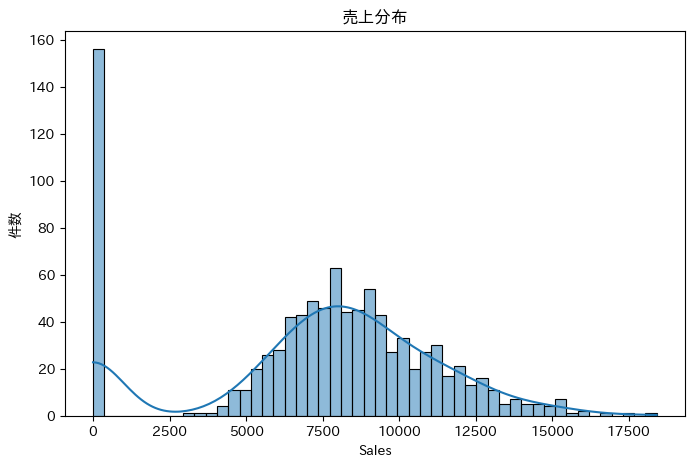

In [844]:
# 売上の分布（Sales distribution）
# 売上の偏り（平均・中央値の差）確認
# 外れ値（特にピーク日の処理が必要）確認

plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("売上分布")
plt.xlabel("Sales")
plt.ylabel("件数")
plt.show()

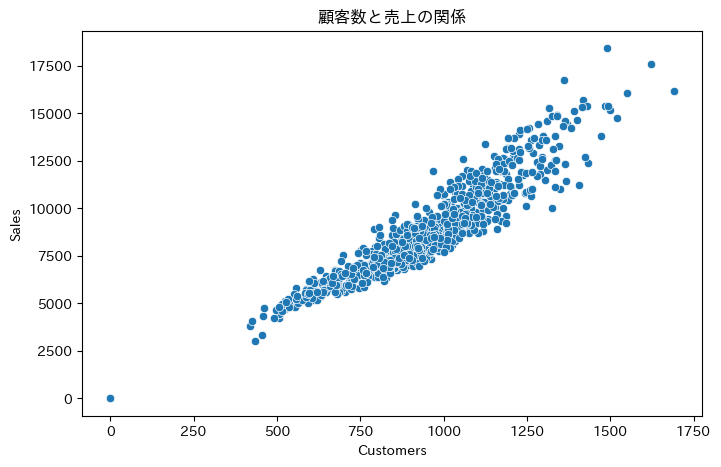

In [845]:
# 売上と顧客数の関係（Sales vs Customers）
# 売上は顧客数に比例するか？
# 外れ値の確認（顧客0で売上があるなど）

plt.figure(figsize=(8,5))
sns.scatterplot(x='Customers', y='Sales', data=df)
plt.title("顧客数と売上の関係")
plt.show()

In [846]:
# 閉店日（Sales=0）の確認
# モデルに含めるか除外するか
# 店舗ごとの閉店日パターンを把握する

closed_days = df[df['Sales'] == 0]
print(closed_days[['Date', 'Store', 'Sales']].head())

          Date  Store  Sales
0   2013-01-01      7      0
5   2013-01-06      7      0
12  2013-01-13      7      0
19  2013-01-20      7      0
26  2013-01-27      7      0


In [847]:
# 予測対象は営業日のみとするため、閉店日を除去
df = df[df["Sales"] > 0]

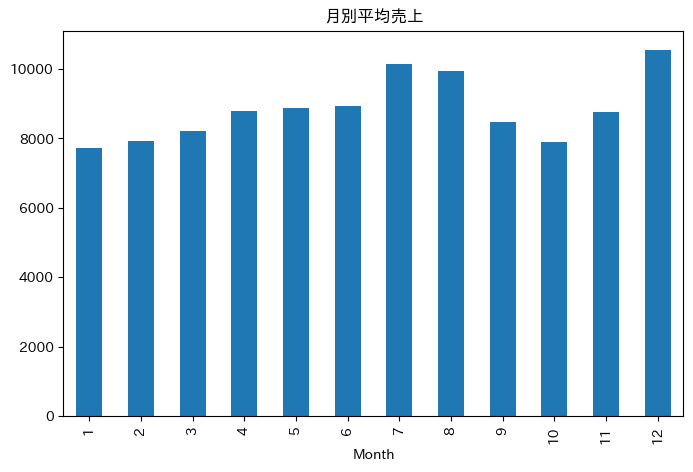

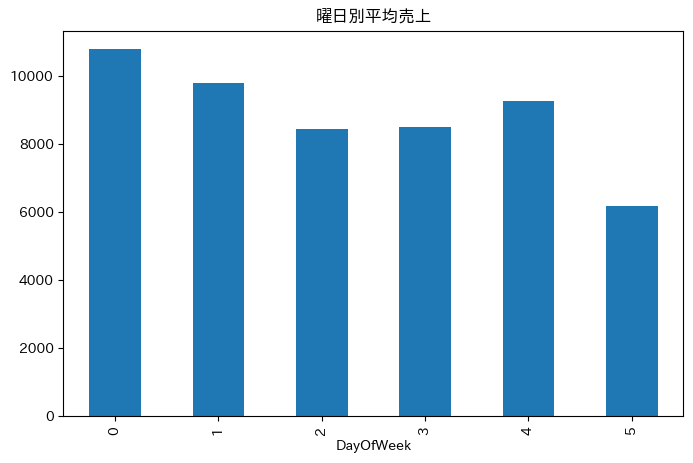

In [848]:
# 時系列トレンド（月・曜日別売上）
# 月や曜日ごとの季節性・週次トレンド
# 特定の曜日や月に売上が偏っていないか

# 日付をdatetimeに変換
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# 月別平均売上
monthly_sales = df.groupby('Month')['Sales'].mean()
monthly_sales.plot(kind='bar', figsize=(8,5), title='月別平均売上')
plt.show()

# 曜日別平均売上
dow_sales = df.groupby('DayOfWeek')['Sales'].mean()
dow_sales.plot(kind='bar', figsize=(8,5), title='曜日別平均売上')
plt.show()

In [849]:
# 日付カラム変換
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [850]:
# dfの欠損値確認
print(df.isna().sum())

Store                          0
DayOfWeek                      0
Date                           0
Sales                          0
Customers                      0
Open                           0
Promo                          0
StateHoliday                   0
SchoolHoliday                  0
StoreType                      0
Assortment                     0
CompetitionDistance            0
CompetitionOpenSinceMonth      0
CompetitionOpenSinceYear       0
Promo2                         0
Promo2SinceWeek              786
Promo2SinceYear              786
PromoInterval                786
Month                          0
dtype: int64


In [851]:
# =======================================================
# 4 特徴量作成
# =======================================================

df["month"] = df["Date"].dt.month
df["day_of_week"] = df["Date"].dt.dayofweek

# ラグ特徴量
df["lag_14"] = df["Sales"].shift(14)
df["lag_28"] = df["Sales"].shift(28)

# 過去14日間、30日間の売上平均
df["rolling_mean_14"] = df["Sales"].shift(14).rolling(window=14).mean()
df["rolling_mean_30"] = df["Sales"].shift(30).rolling(window=30).mean()

# 過去14日間の売上標準偏差
df["rolling_std_14"] = df["Sales"].shift(14).rolling(14).std()


# 欠損行を削除（ラグで最初の7行がNaNになる）
df = df.dropna(subset=[  "month","day_of_week","Promo",
    "SchoolHoliday","lag_14", "lag_28", "rolling_mean_14",
    "rolling_mean_30","rolling_std_14",
]).reset_index(drop=True)

# 確認用
print(f"特徴量作成後の残りデータ件数: {len(df)} 件")

特徴量作成後の残りデータ件数: 727 件


In [852]:
# データ確認
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,Month,month,day_of_week,lag_14,lag_28,rolling_mean_14,rolling_mean_30,rolling_std_14
0,7,1,2013-03-12,7182,920,1,0,0,0,a,...,NaN,NaN,3,3,1,4233.0,8664.0,7114.928571,7439.633333,1774.200685
1,7,2,2013-03-13,6538,781,1,0,0,0,a,...,NaN,NaN,3,3,2,6839.0,8091.0,7025.500000,7441.600000,1752.639800
2,7,3,2013-03-14,6752,783,1,0,0,0,a,...,NaN,NaN,3,3,3,6464.0,4437.0,7170.285714,7489.366667,1599.378987
3,7,4,2013-03-15,8083,946,1,0,0,0,a,...,NaN,NaN,3,3,4,6381.0,7457.0,7093.428571,7500.466667,1610.356851
4,7,5,2013-03-16,5335,566,1,0,0,0,a,...,NaN,NaN,3,3,5,7413.0,6506.0,7158.214286,7474.433333,1603.134726


In [853]:
# =======================================================
# 5 学習データ
# =======================================================

features = [
    "month",
    "day_of_week",
    "Promo",
    "SchoolHoliday", # 学校休日日
    "lag_14",
    "lag_28",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_14",
]

X = df[features]
y = df["Sales"]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[46]	valid_0's rmse: 1048.55	valid_0's l2: 1.09946e+06
Fold1 RMSE(%)       : 12.10%
Fold1 MAE           : 878.04
Fold1 MASE          : 0.360
Fold1 ベースライン比: 64.0% 改善

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[118]	valid_0's rmse: 1648.28	valid_0's l2: 2.71684e+06
Fold2 RMSE(%)       : 15.83%
Fold2 MAE           : 1402.65
Fold2 MASE          : 0.468
Fold2 ベースライン比: 53.2% 改善

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[137]	valid_0's rmse: 1117.23	valid_0's l2: 1.2482e+06
Fold3 RMSE(%)       : 10.64%
Fold3 MAE           : 668.26
Fold3 MASE          : 0.248
Fold3 ベースライン比: 75.2% 改善


CV平均結果
CV平均 RMSE(%)  : 12.86%
CV平均 MAE      : 982.98
CV平均 MASE     : 0.359
ベースライン比  : 64.1% 改善


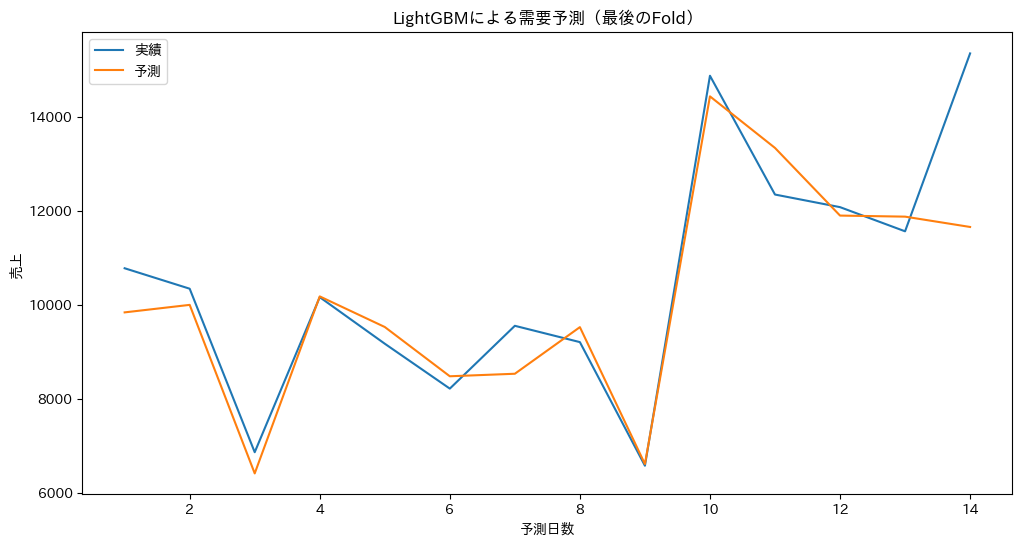

In [854]:
# =======================================================
# 6 Expanding Window CV
# =======================================================

horizon = 14
n_folds = 3

rmse_list = []
mae_list = []
mase_list = []
rmse_pct_list = []

mean_sales = y.mean()

for i in range(n_folds):
    # Foldごとに horizon 日ずつテストセットをスライド
    train_end = len(df) - horizon * (n_folds - i)

    # train_endが十分かチェック
    if train_end <= 0:
        print(f"Fold{i+1} skipped: train_end={train_end}")
        continue

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_test = X.iloc[train_end:train_end + horizon]
    y_test = y.iloc[train_end:train_end + horizon]

    # trainまたはtestが空ならスキップ
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"Fold{i+1} skipped: X_train or X_test is empty")
        continue

    # ----------------------
    # LightGBM モデル
    # ----------------------

    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        importance_type='gain',
        verbosity=-1,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50)]
   )


    # ----------------------
    # 予測
    # ----------------------

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)

    naive_pred = X_test["lag_14"].values
    baseline_mae = mean_absolute_error(y_test, naive_pred)
    mase = mae / baseline_mae

    rmse_pct = rmse / y_test.mean() * 100

    rmse_list.append(rmse)
    mae_list.append(mae)
    mase_list.append(mase)
    rmse_pct_list.append(rmse_pct)

    # 各Fold結果を表示
    print(f"Fold{i+1} RMSE(%)       : {rmse_pct:.2f}%")
    print(f"Fold{i+1} MAE           : {mae:.2f}")
    print(f"Fold{i+1} MASE          : {mase:.3f}")
    print(f"Fold{i+1} ベースライン比: {(1 - mase) * 100:.1f}% 改善")
    print()

    # 最後のfoldだけ保存
    if i == n_folds - 1:
        last_y_test = y_test
        last_pred = pred


# =======================================================
# 7 評価表示
# =======================================================

print()
print("CV平均結果")

rmse_pct = np.mean(rmse_pct_list)
mean_mase = np.mean(mase_list)
improvement = (1 - mean_mase) * 100


print(f"CV平均 RMSE(%)  : {rmse_pct:.2f}%")
print(f"CV平均 MAE      : {np.mean(mae_list):.2f}")
print(f"CV平均 MASE     : {mean_mase:.3f}")
# MASE < 1 なら naive予測（lag_14）より良い
print(f"ベースライン比  : {improvement:.1f}% 改善")

# =======================================================
# 8 予測グラフ
# =======================================================

plt.figure(figsize=(12,6))

x = np.arange(1, len(last_pred) + 1)

plt.plot(x, last_y_test.to_numpy(), label="実績")
plt.plot(x, last_pred, label="予測")

plt.title("LightGBMによる需要予測（最後のFold）")
plt.xlabel("予測日数")
plt.ylabel("売上")

plt.legend()

plt.show()




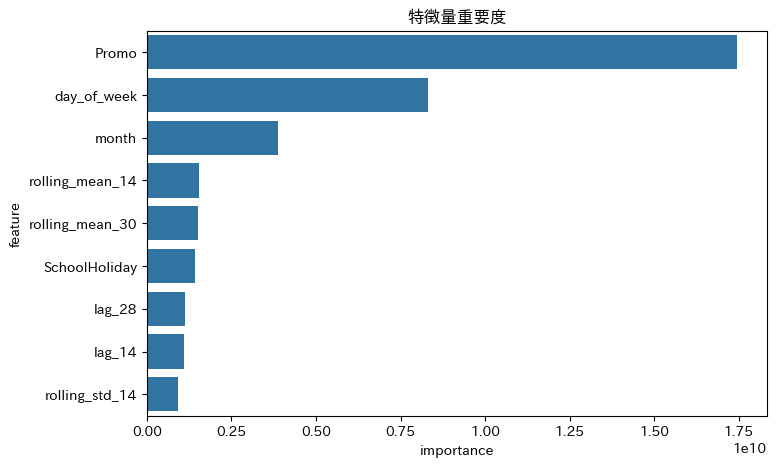

In [855]:
# =======================================================
# 9 特徴量重要度
# =======================================================

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(data=importance, x="importance", y="feature")

plt.title("特徴量重要度")

plt.show()

### ⚙ Feature Importance

LightGBM モデルで予測に寄与した特徴量を可視化しました。  
- このサンプルデータでは、**Promo ** など、プロモーションデータが強く影響していることがわかります。  
 - 曜日・月・休日などのカレンダー情報も一定の重要度を持っており、季節性や週次パターンが予測に貢献しています。  
- **rolling_mean_14, lag_14, lag_28 ** など、直近の売上データも影響していることがわかります。

> この分析から、以下の示唆が得られます：  
> 1. プロモーションの影響が予測に最も重要
> 2. カレンダー情報もモデルの精度向上が期待できる
> 2. 過去の売上データ（移動平均やラグ特徴量）も影響を受けているが、プロモーションやカレンダー情報より低い


今後の改善案：  
-	店舗間の違いを考慮したマルチストアモデル  
-	追加のラグ特徴量  
-	ハイパーパラメータチューニング  
